### Lead Scoring Model
#### Predicting conversion probability for marketing leads
**by Emilia Avila | Data Analytics**

**Dataset:** X Education – 9,240 leads  
**Models:** Logistic Regression vs Random Forest  
**Goal:** Identify which leads are most likely to convert

In [2]:
import pandas as pd                          # Data manipulation and analysis
import numpy as np                           # Numerical computing
import matplotlib.pyplot as plt              # Base plotting library
import seaborn as sns                        # Statistical data visualization
import shap                                  # Model explainability
import math                                  # Basic mathematical functions (e.g. exp, sqrt, log)

from sklearn.model_selection import train_test_split                         # Split data into train/test sets
from sklearn.linear_model import LogisticRegression                          # Logistic Regression model
from sklearn.ensemble import RandomForestClassifier                          # Random Forest model
from sklearn.metrics import classification_report, roc_auc_score, roc_curve  # Model evaluation metrics

import warnings
warnings.filterwarnings('ignore')            # Suppress non-critical warnings

print("Libraries loaded ✓")

Libraries loaded ✓


#### 1. Load Data

In [22]:
# Load dataset
df = pd.read_csv('data/Lead Scoring.csv')

# Display basic info
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
#df.head()

Rows: 9240
Columns: 37


#### 2. Exploratory Data Analysis

In [4]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [5]:
# Check missing values as percentage
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
print("Columns with missing values (%):\n")
print(missing.round(2))

Columns with missing values (%):

Lead Quality                                     51.59
Asymmetrique Activity Index                      45.65
Asymmetrique Profile Score                       45.65
Asymmetrique Activity Score                      45.65
Asymmetrique Profile Index                       45.65
Tags                                             36.29
Lead Profile                                     29.32
What matters most to you in choosing a course    29.32
What is your current occupation                  29.11
Country                                          26.63
How did you hear about X Education               23.89
Specialization                                   15.56
City                                             15.37
Page Views Per Visit                              1.48
TotalVisits                                       1.48
Last Activity                                     1.11
Lead Source                                       0.39
dtype: float64


#### 3. Data Cleaning

In [6]:
# Drop columns with more than 40% missing values or low relevance
cols_to_drop = [
    'Lead Quality', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index',
    'Asymmetrique Activity Score', 'Asymmetrique Profile Score',
    'Tags', 'Lead Profile', 'What matters most to you in choosing a course',
    'Country', 'How did you hear about X Education',
    'Prospect ID', 'Lead Number'  # IDs, not useful for modeling
]

df_clean = df.drop(columns=cols_to_drop)

# Fill remaining missing values with mode (most frequent value)
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Fill numerical nulls with median
for col in df_clean.select_dtypes(include='number').columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

print(f"Remaining columns: {df_clean.shape[1]}")
print(f"Missing values left: {df_clean.isnull().sum().sum()}")

Remaining columns: 25
Missing values left: 0


#### 4. Feature Engineering

Machine learning models only understand numbers — not text. 
This step transforms raw data into a format the model can process.

**Two transformations applied:**

**1. Binary encoding** — columns with Yes/No values are converted to 1/0.  
Example: `Do Not Email`: Yes → 1, No → 0

**2. One-hot encoding** — columns with multiple categories are split into separate binary columns.  
Example: `Lead Source` with values "Google", "Organic Search", "Direct Traffic" becomes:

| Lead Source_Google | Lead Source_Organic Search | Lead Source_Direct Traffic |
|---|---|---|
| 1 | 0 | 0 |
| 0 | 1 | 0 |
| 0 | 0 | 1 |

This is why our dataset grows from 25 to 102 columns after this step. 

Each lead (row) remains unchanged — only new columns are added to represent its category.

In [7]:
# Convert binary text columns to 0/1
binary_cols = ['Do Not Email', 'Do Not Call', 'Search', 'Magazine', 
               'Newspaper Article', 'X Education Forums', 'Newspaper',
               'Digital Advertisement', 'Through Recommendations',
               'Receive More Updates About Our Courses',
               'Update me on Supply Chain Content', 'Get updates on DM Content',
               'I agree to pay the amount through cheque',
               'A free copy of Mastering The Interview']

for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

# Convert remaining categorical columns with get_dummies (one-hot encoding)
df_model = pd.get_dummies(df_clean, drop_first=True)

print(f"Final shape: {df_model.shape}")

Final shape: (9240, 102)


#### 5. Model Training

Before training, we split the dataset into two sets:

- **Training set (80%)** — the data the model learns from
- **Test set (20%)** — unseen data used to evaluate how well the model generalizes

We use `random_state=42` to ensure the split is always the same, making results reproducible.

The model will never see the test set during training — this way we get an honest measure of its performance.

In [8]:
# Define features and target variable
X = df_model.drop(columns='Converted')  # All columns except the target
y = df_model['Converted']               # What we want to predict

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 7392 rows
Test set: 1848 rows


We train two models and will compare their performance:

**Logistic Regression** — a simple, interpretable model that predicts 
the probability of conversion. Good baseline and easy to explain to stakeholders.

**Random Forest** — an ensemble of 100 decision trees that vote together 
to make a prediction. More powerful but less interpretable than Logistic Regression.

In [9]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)  # max_iter ensures the model converges
lr_model.fit(X_train, y_train)                # Train on training set

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # 100 decision trees
rf_model.fit(X_train, y_train)                                        # Train on training set

print("Models trained ✓")

Models trained ✓


#### 6. Model Evaluation

We evaluate both models on the test set — data they have never seen before.

Key metrics:
- **Precision** — of all leads predicted as converted, how many actually did?
- **Recall** — of all leads that actually converted, how many did we catch?
- **F1-score** — balance between precision and recall
- **Accuracy** — overall percentage of correct predictions

In [10]:
# Predictions
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Classification reports
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1107
           1       0.82      0.72      0.77       741

    accuracy                           0.82      1848
   macro avg       0.82      0.81      0.81      1848
weighted avg       0.82      0.82      0.82      1848

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1107
           1       0.80      0.77      0.78       741

    accuracy                           0.83      1848
   macro avg       0.82      0.82      0.82      1848
weighted avg       0.83      0.83      0.83      1848



AUC-ROC measures how well the model separates converted vs non-converted leads,
regardless of class imbalance. Score ranges from 0.5 (random) to 1.0 (perfect).

- 0.70 - 0.80 → Acceptable
- 0.80 - 0.90 → Good
- 0.90+ → Excellent

In [11]:
# Calculate AUC-ROC for both models
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print(f"Logistic Regression AUC-ROC: {lr_auc:.3f}")
print(f"Random Forest AUC-ROC:       {rf_auc:.3f}")

Logistic Regression AUC-ROC: 0.900
Random Forest AUC-ROC:       0.898


**Results Summary**

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 82% | 83% |
| Precision (class 1) | 82% | 80% |
| Recall (class 1) | 72% | 77% |
| AUC-ROC | 0.900 | 0.898 |

**Verdict: Logistic Regression is the recommended model.**

Although Random Forest has slightly higher accuracy and recall, 
Logistic Regression wins on AUC-ROC and is more interpretable — 
making it easier to explain to business stakeholders why a lead scores high.

#### 7. ROC Curve

The ROC curve shows the tradeoff between:
- **True Positive Rate (Recall)** — leads that converted and were correctly identified
- **False Positive Rate** — leads that didn't convert but were predicted as conversions

The closer the curve is to the top-left corner, the better the model.
The dashed line represents a random model (AUC = 0.500) — our baseline to beat.

Both models perform excellently, with Logistic Regression slightly ahead.

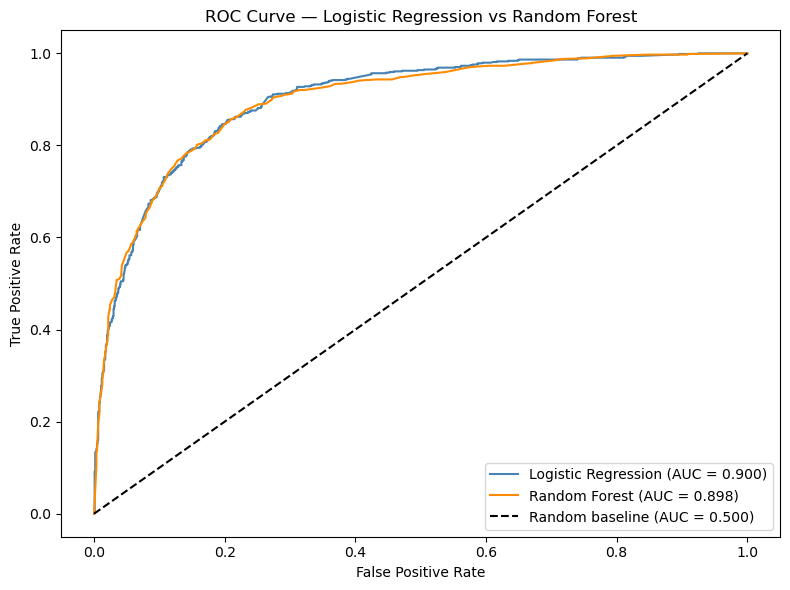

In [12]:
# Calculate ROC curves for both models
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_model.predict_proba(X_test)[:, 1])
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])

# Plot
plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})', color='steelblue')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline (AUC = 0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression vs Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

#### 8. Feature Importance by Model

Different models measure variable importance differently. Here we compare both to get a complete picture of what drives conversion:

**Random Forest — Feature Importance**

Random Forest measures how often each variable was used to split the trees and how much it improved the separation between converted and non-converted leads.

**Logistic Regression — Coefficients**

Logistic Regression measures the weight assigned to each variable in the equation. 
Unlike Random Forest, coefficients have direction — positive values push toward 
conversion, negative values push away from it.

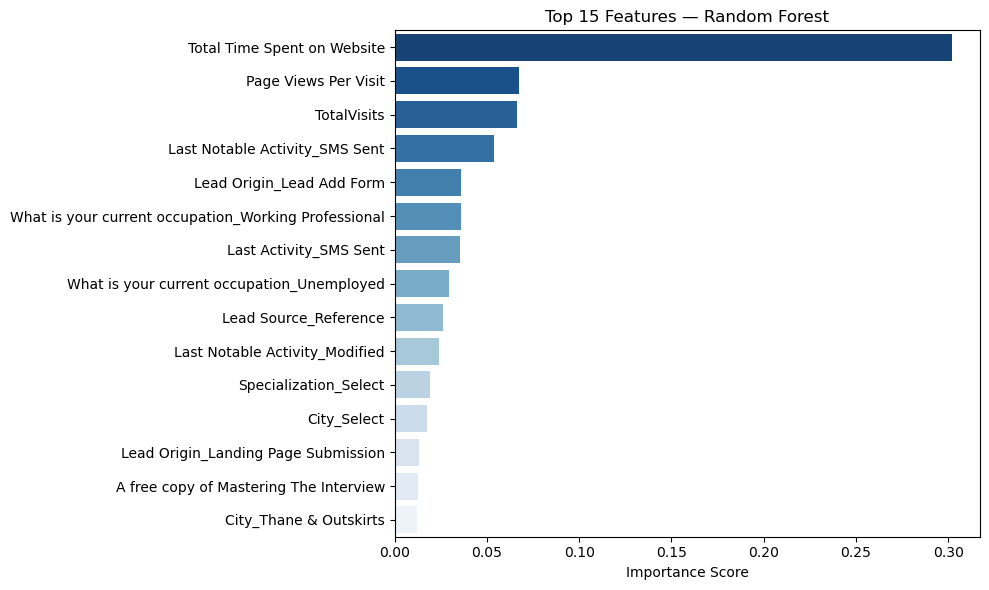

In [13]:
# Get feature importance from Random Forest
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette='Blues_r')
plt.title('Top 15 Features — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

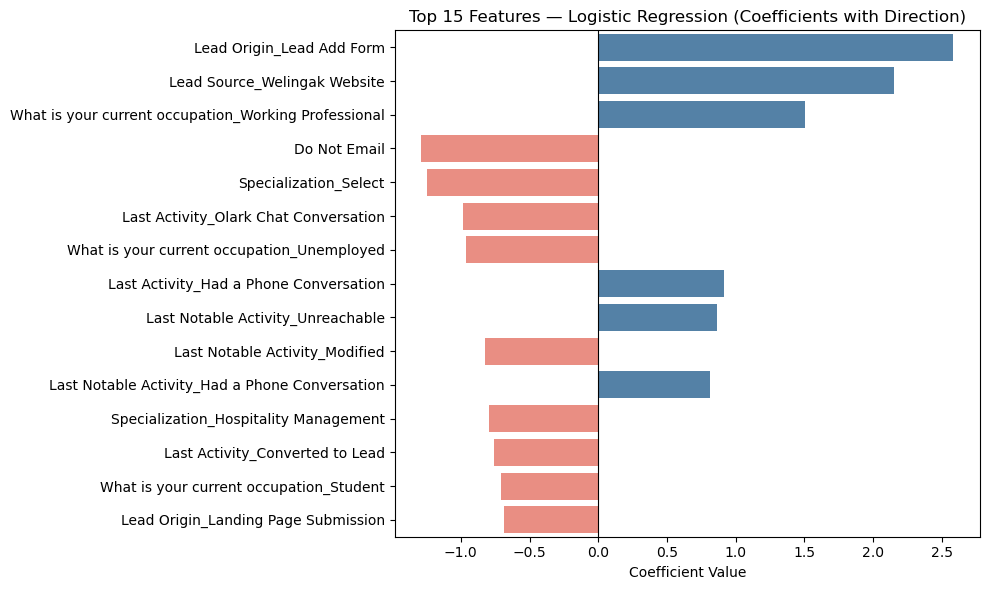

In [14]:
# Logistic Regression — Coefficients with direction
coefs = pd.Series(lr_model.coef_[0], index=X.columns)
top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).head(15).index)

colors = ['steelblue' if c > 0 else 'salmon' for c in top_coefs.values]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_coefs.values, y=top_coefs.index, palette=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 15 Features — Logistic Regression (Coefficients with Direction)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

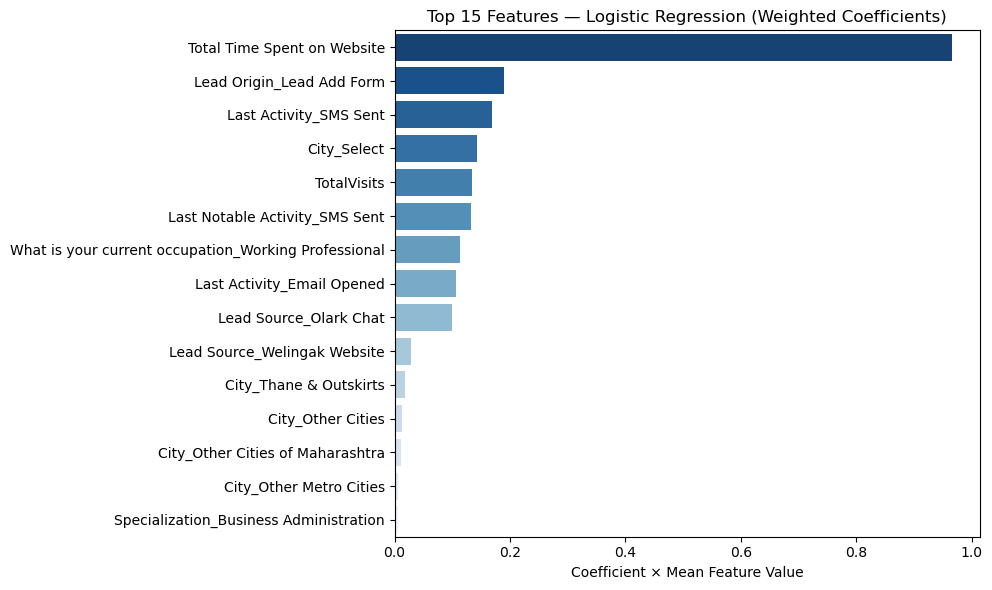

In [15]:
# Logistic Regression — Weighted coefficients (coefficient × mean feature value)
coefs = pd.Series(lr_model.coef_[0], index=X.columns)
means = X_train.mean()
weighted_coefs = (coefs * means)

top_weighted = weighted_coefs[weighted_coefs > 0].sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_weighted.values, y=top_weighted.index, palette='Blues_r')
plt.title('Top 15 Features — Logistic Regression (Weighted Coefficients)')
plt.xlabel('Coefficient × Mean Feature Value')
plt.tight_layout()
plt.show()

**Why two charts for Logistic Regression?**

Logistic Regression coefficients have a scaling problem — variables with large numeric ranges 
(like Total Time Spent on Website) get small raw coefficients that don't reflect their real impact. 
For example, Total Time Spent on Website has a coefficient of 0.002, but leads spend hundreds of 
seconds on the site on average, making its real contribution one of the largest in the model.

- **Chart 1 (raw coefficients)** — best for understanding direction and the weight of categorical 
variables like Lead Origin and Occupation.

- **Chart 2 (weighted coefficients)** — corrects for scale by multiplying each coefficient by the 
average value of that variable. Use this chart to compare with Random Forest.

**Random Forest vs Logistic Regression — do they agree?**

Once we correct for scale, both models tell the same story: behavioral signals and lead origin are the strongest drivers of conversion.

| Driver | Random Forest | Logistic Regression (weighted) |
|---|---|---|
| Total Time Spent on Website | #1 | #1 |
| Lead Origin_Lead Add Form | #5 | #2 |
| TotalVisits | #3 | #5 |
| Working Professional | #6 | #7 |

#### 9. Predicting New Leads

Now that the model is trained, we can use it to score new leads.

To simulate a real-world scenario, we create 10 fictional leads with different profiles — 
some with strong conversion signals, some weak, and some contradictory.

In [24]:
# 10 fictional leads with different profiles
new_leads_raw = pd.DataFrame({
    'Lead Origin': [
        'Lead Add Form', 'API', 'Landing Page Submission', 'API',
        'Landing Page Submission', 'API', 'Lead Add Form', 'API',
        'Landing Page Submission', 'Landing Page Submission'
    ],
    'Lead Source': [
        'Welingak Website', 'Google', 'Landing Page Submission', 'Direct Traffic',
        'Welingak Website', 'Reference', 'Direct Traffic', 'Google',
        'Organic Search', 'Welingak Website'
    ],
    'Do Not Email': [
        'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No'
    ],
    'Do Not Call': [
        'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No'
    ],
    'TotalVisits': [
        10, 5, 2, 1, 9, 8, 3, 4, 4, 7
    ],
    'Total Time Spent on Website': [
        1500, 600, 150, 80, 1400, 1200, 400, 200, 500, 1100
    ],
    'Page Views Per Visit': [
        5.0, 3.0, 1.5, 1.0, 4.5, 4.0, 2.0, 1.8, 2.5, 3.8
    ],
    'Last Activity': [
        'Olark Chat Conversation', 'Email Opened', 'Page Visited on Website',
        'Email Bounced', 'Had a Phone Conversation', 'Page Visited on Website',
        'Email Opened', 'Page Visited on Website', 'Email Opened',
        'Olark Chat Conversation'
    ],
    'Specialization': [
        'Finance Management', 'IT Projects Management', 'Select', 'Select',
        'Business Administration', 'Media and Advertising', 'Select',
        'Finance Management', 'Select', 'IT Projects Management'
    ],
    'What is your current occupation': [
        'Working Professional', 'Working Professional', 'Student', 'Unemployed',
        'Working Professional', 'Student', 'Unemployed', 'Working Professional',
        'Student', 'Student'
    ],
    'Search':                                ['No'] * 10,
    'Magazine':                              ['No'] * 10,
    'Newspaper Article':                     ['No'] * 10,
    'X Education Forums':                    ['No'] * 10,
    'Newspaper':                             ['No'] * 10,
    'Digital Advertisement':                 ['No'] * 10,
    'Through Recommendations':               ['No'] * 10,
    'Receive More Updates About Our Courses':['No'] * 10,
    'Update me on Supply Chain Content':     ['No'] * 10,
    'Get updates on DM Content':             ['No'] * 10,
    'I agree to pay the amount through cheque': ['No'] * 10,
    'A free copy of Mastering The Interview':['No'] * 10,
    'Last Notable Activity': [
        'Modified', 'Email Opened', 'Page Visited on Website', 'Unreachable',
        'Had a Phone Conversation', 'Modified', 'Email Opened',
        'Page Visited on Website', 'Email Opened', 'Modified'
    ],
    'City': [
        'Mumbai', 'Mumbai', 'Other Cities', 'Select', 'Mumbai',
        'Thane & Outskirts', 'Select', 'Other Metro Cities', 'Select', 'Mumbai'
    ],
})

print(f"New leads created: {new_leads_raw.shape[0]} rows, {new_leads_raw.shape[1]} columns")
#new_leads_raw.head()

New leads created: 10 rows, 24 columns


Before predicting, we apply the exact same transformations used during training.
This is critical — the model expects data in the same format it was trained on.

In [25]:
# Step 1: Apply binary encoding (Yes/No → 1/0)
for col in binary_cols:
    if col in new_leads_raw.columns:
        new_leads_raw[col] = new_leads_raw[col].map({'Yes': 1, 'No': 0})

# Step 2: Apply one-hot encoding
new_leads_encoded = pd.get_dummies(new_leads_raw)

# Step 3: Align columns with training data — add missing columns as 0
new_leads_encoded = new_leads_encoded.reindex(columns=X.columns, fill_value=0)

print(f"Columns after encoding: {new_leads_encoded.shape[1]}")
print(f"Columns match training data: {new_leads_encoded.shape[1] == X.shape[1]}")

Columns after encoding: 101
Columns match training data: True


We use predict_proba() instead of predict() because we want the probability 
of conversion, not just a binary yes/no. This gives us a score we can use to rank leads.

In [26]:
# Predict conversion probability for each lead
probabilities = lr_model.predict_proba(new_leads_encoded)[:, 1]

# Preview raw probabilities
for i, prob in enumerate(probabilities):
    print(f"Lead {i+1}: {prob:.1%} probability of conversion")

Lead 1: 100.0% probability of conversion
Lead 2: 91.2% probability of conversion
Lead 3: 7.4% probability of conversion
Lead 4: 6.2% probability of conversion
Lead 5: 100.0% probability of conversion
Lead 6: 70.8% probability of conversion
Lead 7: 74.4% probability of conversion
Lead 8: 80.5% probability of conversion
Lead 9: 18.7% probability of conversion
Lead 10: 80.9% probability of conversion


Finally, we display the results as a ranked table — ordered by conversion score. 
This is what a sales team would use to prioritize their outreach.

In [27]:
results = pd.DataFrame({
    'Lead':             [f'Lead {i+1}' for i in range(10)],
    'Occupation':       new_leads_raw['What is your current occupation'].values,
    'Lead Origin':      new_leads_raw['Lead Origin'].values,
    'Lead Source':      new_leads_raw['Lead Source'].values,
    'Time on Website':  new_leads_raw['Total Time Spent on Website'].values,
    'Conversion Score': (probabilities * 100).round(1)
}).sort_values('Conversion Score', ascending=False).reset_index(drop=True)

results.index += 1
results

,Lead,Occupation,Lead Origin,Lead Source,Time on Website,Conversion Score
1,Lead 1,Working Professional,Lead Add Form,Welingak Website,1500,100.0
2,Lead 5,Working Professional,Landing Page Submission,Welingak Website,1400,100.0
3,Lead 2,Working Professional,API,Google,600,91.2
4,Lead 10,Student,Landing Page Submission,Welingak Website,1100,80.9
5,Lead 8,Working Professional,API,Google,200,80.5
6,Lead 7,Unemployed,Lead Add Form,Direct Traffic,400,74.4
7,Lead 6,Student,API,Reference,1200,70.8
8,Lead 9,Student,Landing Page Submission,Organic Search,500,18.7
9,Lead 3,Student,Landing Page Submission,Landing Page Submission,150,7.4
10,Lead 4,Unemployed,API,Direct Traffic,80,6.2


The model ranked 10 fictional leads by conversion probability, revealing three clear patterns:

**1. Occupation + Lead Origin drive the top scores**  
The top 3 leads are all Working Professionals. Combined with strong lead origins 
(Lead Add Form, Welingak Website), the model assigns them 91–100% conversion probability.

**2. Time on website can compensate for a weaker profile**  
Lead 10 is a Student — typically a weaker signal — but spent 1,100 seconds on the website 
and scored 80.9%, higher than Lead 8, a Working Professional who only spent 200 seconds.  
Behavioral signals can outweigh demographic ones.

**3. Lead Origin alone can rescue a weak profile**  
Lead 7 is Unemployed, but came through Lead Add Form — one of the strongest origin signals — 
and still scored 74.4%. The model balances all variables rather than relying on a single one.

**Business takeaway:** Sales teams should prioritize leads with scores above 70%, 
focusing first on Working Professionals with high website engagement. 
However, high-engagement Students should not be ignored — they can convert at similar rates.

#### 10. Explainability with SHAP

Building a model is only half the job. The other half is being able to explain it.

When a sales team asks *"why does this lead have a high score?"*, 
a black-box answer is not enough. SHAP (SHapley Additive exPlanations) 
solves this by breaking down each individual prediction into contributions 
from each variable — showing exactly what pushed the score up or down.

This is especially important with Logistic Regression, our chosen model, 
because every prediction can be traced back to specific variables. 
SHAP makes that visible.

**How to read the waterfall chart:**
- 🔴 Red bars → variable pushed the score **up** (toward conversion)

- 🔵 Blue bars → variable pushed the score **down** (away from conversion)

- The final score is the sum of all contributions

In the following example, we explain Lead 7 — an Unemployed lead that scored 74.4%.

'Unemployed' is typically a weak signal, but 'Lead Add Form' origin pushed the score up significantly.

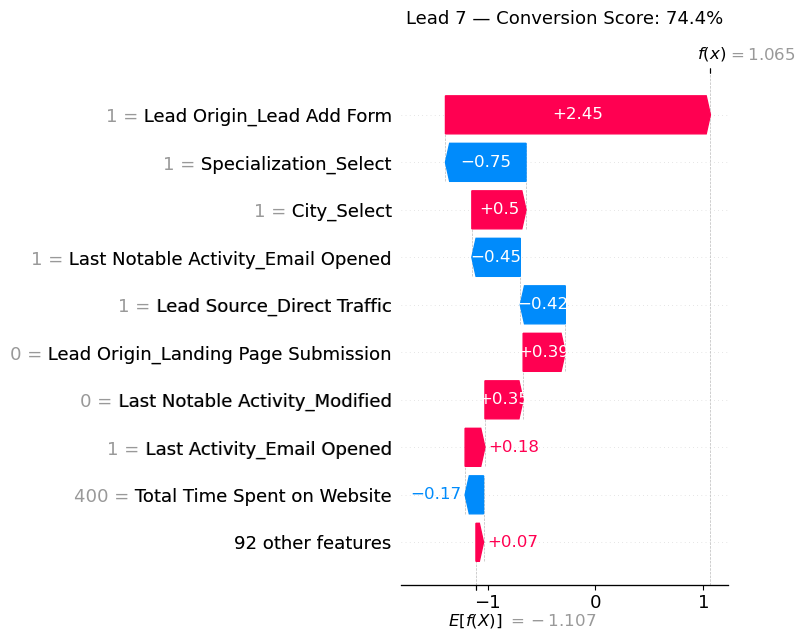

In [35]:
# Create SHAP explainer using training data as background
explainer = shap.Explainer(lr_model, X_train)

# Calculate SHAP values for Lead 7 (index 6)
lead_7 = new_leads_encoded.iloc[[6]]
shap_values = explainer(lead_7)
lead_7_score = probabilities[6]

# Waterfall chart
shap.plots.waterfall(shap_values[0], show=False)
plt.title(f'Lead 7 — Conversion Score: {lead_7_score:.1%}', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

**Starting Point:**

E[f(X)] = −1.107 (≈ 25% conversion probability)

Before looking at any lead data, the model starts with the average conversion 
probability of the entire dataset. Most leads don't convert, so the baseline is low.

**Key Contributions:**

- Lead Origin_Lead Add Form → +2.45 — by far the strongest signal, single-handedly rescued this lead
- Specialization_Select → −0.75 — no specialization defined, penalizes the score
- Lead Source_Direct Traffic → −0.42 — not a strong acquisition channel
- Total Time Spent on Website → −0.17 — 400 seconds is below average

**Final result:**

All contributions added together land at 1.065 in log-odds scale.  
The sigmoid function converts that to a human-readable probability:

> sigmoid(1.065) = **74.4% conversion probability**

Lead 7 scores 74.4% almost entirely because of Lead Add Form. 
Without that origin, this Unemployed lead would likely score below 50%.

In [29]:
def sigmoid(x):
    return 1 / (1 + math.exp(-x))

# Lead 7 example
log_odds = shap_values[0].base_values + shap_values[0].values.sum()
probability = sigmoid(log_odds)

print(f"Base value:        {shap_values[0].base_values:.3f}")
print(f"Sum of SHAP:       {shap_values[0].values.sum():.3f}")
print(f"Final log-odds:    {log_odds:.3f}")
print(f"sigmoid({log_odds:.3f}) = {probability:.1%}")

Base value:        -1.107
Sum of SHAP:       2.172
Final log-odds:    1.065
sigmoid(1.065) = 74.4%


#### 11. Conclusions

- **Logistic Regression was selected** as the production model with AUC-ROC of 0.900 — marginally better than Random Forest (0.898) and significantly more interpretable for business stakeholders.

- **Behavioral signals and lead origin are the strongest drivers of conversion** — Total Time Spent on Website, Page Views, and Total Visits reflect active engagement, while Lead Origin (Lead Add Form, Welingak Website) signals high-intent entry points. Notably, high website engagement can compensate for a weaker demographic profile — a Student with 1,100 seconds on site scored higher than a Working Professional with only 200 seconds.

- **SHAP explainability bridges model and business** — every individual prediction can be decomposed into variable contributions, allowing sales teams to understand why a lead scored high or low.

- **Next steps:** retrain periodically with new data, calibrate the decision threshold based on business priorities (precision vs recall), and explore ensemble methods or XGBoost for potential performance gains.